# Exploring Gender & Rank Differences in Employee Salaries.

## Importing Python Libraries

In [11]:
import pandas as pd

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

In [13]:
df = pd.read_csv("https://raw.githubusercontent.com/CunyLaguardiaDataAnalytics/datasets/master/Salaries.csv")

## Understanding the Dataset

In [14]:
df

,Unnamed: 0,rank,discipline,yrs.since.phd,yrs.service,sex,salary
0,1,Prof,B,19,18,Male,139750
1,2,Prof,B,20,16,Male,173200
2,3,AsstProf,B,4,3,Male,79750
3,4,Prof,B,45,39,Male,115000
4,5,Prof,B,40,41,Male,141500
...,...,...,...,...,...,...,...
392,393,Prof,A,33,30,Male,103106
393,394,Prof,A,31,19,Male,150564
394,395,Prof,A,42,25,Male,101738
395,396,Prof,A,25,15,Male,95329


In [15]:
df.head()

,Unnamed: 0,rank,discipline,yrs.since.phd,yrs.service,sex,salary
0,1,Prof,B,19,18,Male,139750
1,2,Prof,B,20,16,Male,173200
2,3,AsstProf,B,4,3,Male,79750
3,4,Prof,B,45,39,Male,115000
4,5,Prof,B,40,41,Male,141500


In [16]:
df.tail()

,Unnamed: 0,rank,discipline,yrs.since.phd,yrs.service,sex,salary
392,393,Prof,A,33,30,Male,103106
393,394,Prof,A,31,19,Male,150564
394,395,Prof,A,42,25,Male,101738
395,396,Prof,A,25,15,Male,95329
396,397,AsstProf,A,8,4,Male,81035


In [8]:
df.columns

Index(['Unnamed: 0', 'rank', 'discipline', 'yrs.since.phd', 'yrs.service',
       'sex', 'salary'],
      dtype='object')

In [17]:
df.dtypes

Unnamed: 0        int64
rank             object
discipline       object
yrs.since.phd     int64
yrs.service       int64
sex              object
salary            int64
dtype: object

In [18]:
print(df.head())

   Unnamed: 0      rank discipline  yrs.since.phd  yrs.service   sex  salary
0           1      Prof          B             19           18  Male  139750
1           2      Prof          B             20           16  Male  173200
2           3  AsstProf          B              4            3  Male   79750
3           4      Prof          B             45           39  Male  115000
4           5      Prof          B             40           41  Male  141500


#data exploration - mean/median of all salaries, median salary by gender and/or rank/title, etc.

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397 entries, 0 to 396
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Unnamed: 0     397 non-null    int64 
 1   rank           397 non-null    object
 2   discipline     397 non-null    object
 3   yrs.since.phd  397 non-null    int64 
 4   yrs.service    397 non-null    int64 
 5   sex            397 non-null    object
 6   salary         397 non-null    int64 
dtypes: int64(4), object(3)
memory usage: 21.8+ KB


## Data exploration - mean/median of all salaries, median salary by gender and/or rank/title, etc.

In [20]:
df.describe()

,Unnamed: 0,yrs.since.phd,yrs.service,salary
count,397.000000,397.000000,397.000000,397.000000
mean,199.000000,22.314861,17.614610,113706.458438
std,114.748275,12.887003,13.006024,30289.038695
min,1.000000,1.000000,0.000000,57800.000000
25%,100.000000,12.000000,7.000000,91000.000000
50%,199.000000,21.000000,16.000000,107300.000000
75%,298.000000,32.000000,27.000000,134185.000000
max,397.000000,56.000000,60.000000,231545.000000


In [21]:
df.shape

(397, 7)

In [22]:
df.columns.tolist()

['Unnamed: 0',
 'rank',
 'discipline',
 'yrs.since.phd',
 'yrs.service',
 'sex',
 'salary']

In [23]:
df["salary"].describe()

count       397.000000
mean     113706.458438
std       30289.038695
min       57800.000000
25%       91000.000000
50%      107300.000000
75%      134185.000000
max      231545.000000
Name: salary, dtype: float64

In [24]:
"mean salary:",df["salary"].mean()

('mean salary:', 113706.45843828715)

In [25]:
"Median salary:",df['salary'].median()

('Median salary:', 107300.0)

In [27]:
 df.groupby("sex")["salary"].median().sort_values(ascending=False)

sex
Male      108043.0
Female    103750.0
Name: salary, dtype: float64

In [29]:
df.groupby("rank")["salary"].median().sort_values(ascending=False)

rank
Prof         123321.5
AssocProf     95626.5
AsstProf      79800.0
Name: salary, dtype: float64

In [33]:
df.groupby(["rank", "sex"])["salary"].median().unstack()

sex,Female,Male
rank,,
AssocProf,90556.5,95626.5
AsstProf,77000.0,80182.0
Prof,120257.5,123996.0


In [34]:
df.groupby(["rank", "sex"])["salary"].agg(
          employees="count",
          mean_salary="mean",
          median_salary="median",
          minimum_salary="min",
          maximum_salary="max"
      ).round(2).reset_index()

,rank,sex,employees,mean_salary,median_salary,minimum_salary,maximum_salary
0,AssocProf,Female,10,88512.80,90556.5,62884,109650
1,AssocProf,Male,54,94869.70,95626.5,70000,126431
2,AsstProf,Female,11,78049.91,77000.0,63100,97032
3,AsstProf,Male,56,81311.46,80182.0,63900,95079
4,Prof,Female,18,121967.61,120257.5,90450,161101
5,Prof,Male,248,127120.82,123996.0,57800,231545


## data wrangling - renaming columns, subsetting columns, handling missing data, etc.

In [35]:
df.isnull()

,Unnamed: 0,rank,discipline,yrs.since.phd,yrs.service,sex,salary
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
392,False,False,False,False,False,False,False
393,False,False,False,False,False,False,False
394,False,False,False,False,False,False,False
395,False,False,False,False,False,False,False


In [36]:
df.isnull().sum()

Unnamed: 0       0
rank             0
discipline       0
yrs.since.phd    0
yrs.service      0
sex              0
salary           0
dtype: int64

In [37]:
df.isnull().sum().sum()

0

In [38]:
df=df.rename(
    columns={
        "Unnamed: 0": "registration number",
        "rank":"title",
        "sex": "gender"
    }
)

In [43]:
df.columns.tolist()

['registration number',
 'title',
 'discipline',
 'yrs.since.phd',
 'yrs.service',
 'gender',
 'salary']

In [49]:
df.groupby(['gender'])['registration number'].count().sort_values(ascending=False)

gender
Male      358
Female     39
Name: registration number, dtype: int64

In [48]:
df.groupby(['discipline'])['registration number'].count().sort_values(ascending=False)

discipline
B    216
A    181
Name: registration number, dtype: int64

In [52]:
df.groupby(['gender'])['registration number'].count().sort_values(ascending=False)

gender
Male      358
Female     39
Name: registration number, dtype: int64

## data visualizations - show some stats

### Overall salary distribution

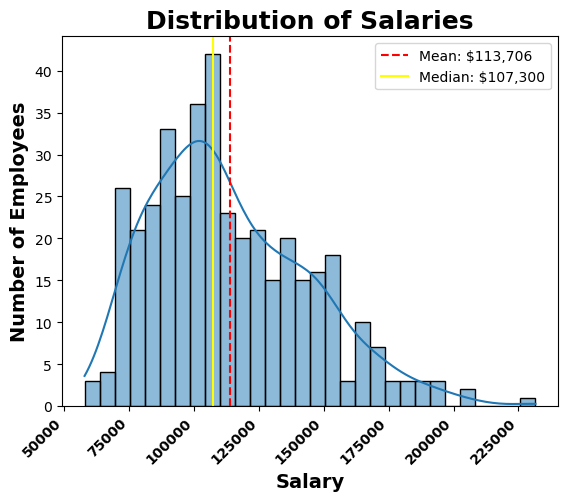

In [110]:
mean_salary = df["salary"].mean()
median_salary = df["salary"].median()

sns.histplot(data=df, x="salary", bins=30, kde=True)

plt.axvline(
    mean_salary,
    color="red",
    linestyle="--",
    label=f"Mean: ${mean_salary:,.0f}"
)

plt.axvline(
    median_salary,
    color="yellow",
    linestyle="-",
    label=f"Median: ${median_salary:,.0f}"
)
plt.xticks (rotation=45, ha="right", fontweight="bold")
plt.title("Distribution of Salaries", fontsize=18, fontweight="bold")
plt.xlabel("Salary" , fontsize=14, fontweight="bold")
plt.ylabel("Number of Employees", fontsize=14, fontweight="bold")
plt.legend()
plt.show()

### Median salary by gender

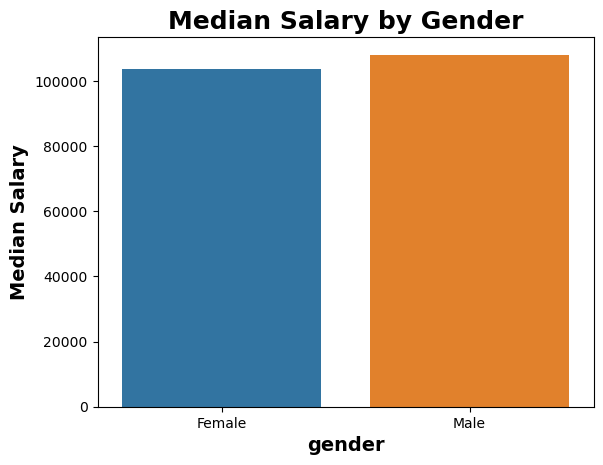

   gender  median_salary  mean_salary  employees
0  Female       103750.0   101002.410         39
1    Male       108043.0   115090.419        358


In [90]:
g_statits = (
    df.groupby('gender', as_index=False)
      .agg(
          median_salary=("salary", "median"),
          mean_salary=("salary", "mean"),
          employees=("salary", "count")
      )
)

sns.barplot(
    data=g_statits,
    x="gender",
    y="median_salary",
    hue="gender",
    legend=False
)

plt.title("Median Salary by Gender", fontsize=18, fontweight="bold")
plt.xlabel("gender", fontsize=14, fontweight="bold")
plt.ylabel("Median Salary", fontsize=14, fontweight="bold")
plt.show()

print(g_statits.round(3))

### Median salary by rank or title

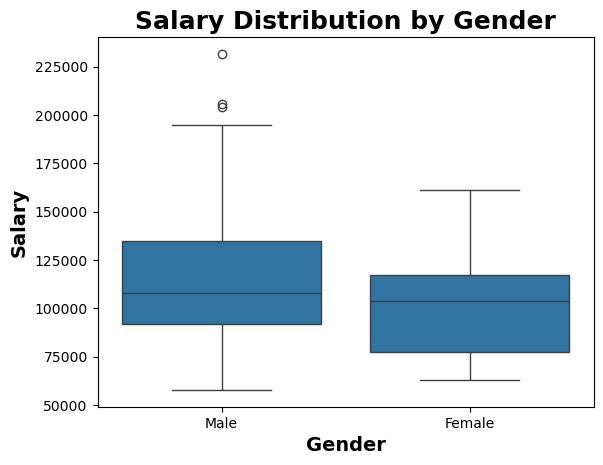

In [91]:
sns.boxplot(data=df, x="gender", y="salary")

plt.title("Salary Distribution by Gender", fontsize=18, fontweight="bold")
plt.xlabel("Gender", fontsize=14, fontweight="bold")
plt.ylabel("Salary", fontsize=14, fontweight="bold")
plt.show()

### Median salary by rank or title

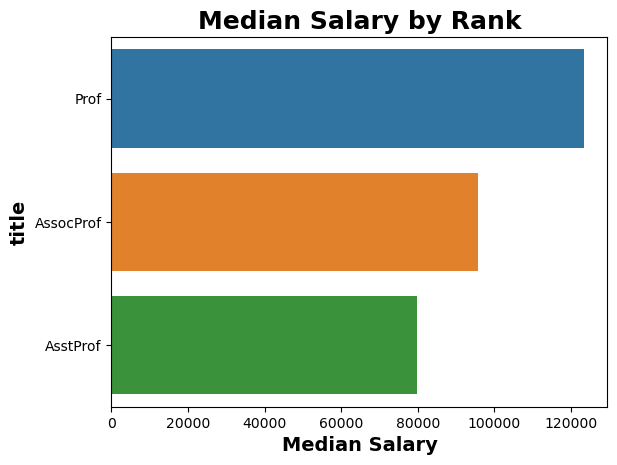

       title  median_salary  mean_salary  employees
2       Prof       123321.5    126772.11        266
0  AssocProf        95626.5     93876.44         64
1   AsstProf        79800.0     80775.99         67


In [109]:
title_stats = (
    df.groupby("title", as_index=False)
      .agg(
          median_salary=("salary", "median"),
          mean_salary=("salary", "mean"),
          employees=("salary", "count")
      )
      .sort_values("median_salary", ascending=False)
)

sns.barplot(
    data=title_stats,
    y="title", 
    x="median_salary",
    hue="title",
    legend=False
)

plt.title("Median Salary by Rank", fontsize=18, fontweight="bold")
plt.xlabel("Median Salary", fontsize=14, fontweight="bold")
plt.ylabel("title", fontsize=14, fontweight="bold")
plt.show()

print(title_stats.round(2))

### Median salary by gender within rank

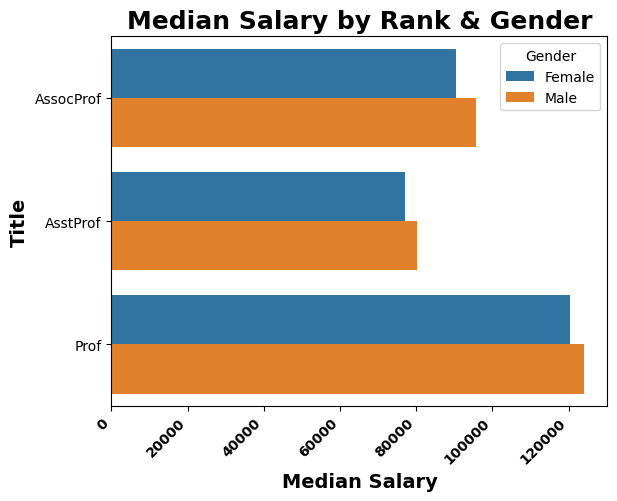

       title  gender  median_salary  mean_salary  employees
0  AssocProf  Female        90556.5     88512.80         10
1  AssocProf    Male        95626.5     94869.70         54
2   AsstProf  Female        77000.0     78049.91         11
3   AsstProf    Male        80182.0     81311.46         56
4       Prof  Female       120257.5    121967.61         18
5       Prof    Male       123996.0    127120.82        248


In [113]:
rank_gender_stats = (
    df.groupby(["title", "gender"], as_index=False)
      .agg(
          median_salary=("salary", "median"),
          mean_salary=("salary", "mean"),
          employees=("salary", "count")
      )
)
sns.barplot(
    data=rank_gender_stats,
    x="median_salary",
    y="title",
    hue="gender"
)
plt.xticks (rotation=45, ha="right", fontweight="bold")
plt.title("Median Salary by Rank & Gender",fontsize=18, fontweight="bold")
plt.xlabel("Median Salary", fontsize=14, fontweight="bold")
plt.ylabel("Title", fontsize=14, fontweight="bold")
plt.legend(title="Gender")
plt.show()

print(rank_gender_stats.round(2))

### SALARY VERSUS YEARS OF EXPERIENCE

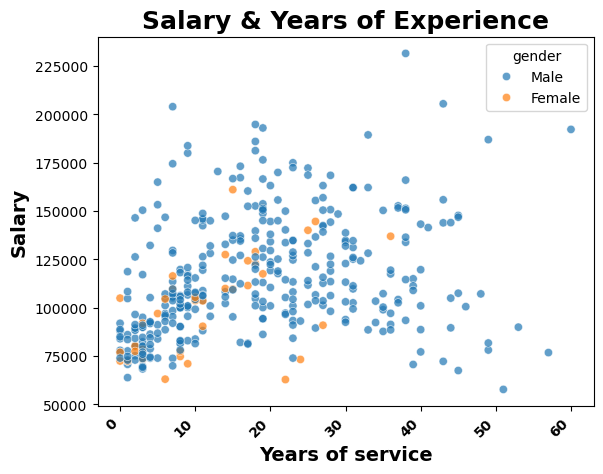

In [118]:

sns.scatterplot(
    data=df,
    x="yrs.service",
    y="salary",
    hue="gender",
    alpha=0.7
)
plt.xticks(rotation=45, ha="right", fontweight="bold")
plt.title("Salary & Years of Experience",fontsize=18, fontweight="bold")
plt.xlabel("Years of service", fontsize=14, fontweight="bold")
plt.ylabel("Salary", fontsize=14, fontweight="bold")
plt.show()

## conclusions - what did you discover?

The exploratoty analysis found that male employees earned more, than female employees on both the median and mean measures.  
The median difference was relaatively modes at $4,293, while mean difference was substantially larger $ 14,088.
The pattern suggests that men may be more heavely reprented among the highest-paid employment.
However, because women represent only 9.8% of the sample and the analysis does not yet account for rank, title, experience, or department,  
the results should be interpreted as descriptive evidence of a salary difference rather than proof of gender-based pay discrimination.